# TP : Reconstruction et Fusion Multimodale (IRM + Échographie) avec Segmentation

**Objectif :**  
Simuler deux modalités d’imagerie médicale (IRM et échographie) à partir d’un phantom anatomique,  
reconstruire, débruiter et fusionner les deux images, puis appliquer une **segmentation automatique**  
pour comparer la précision et la richesse de la fusion.

**Bibliothèques utilisées :**
- `numpy`, `matplotlib` → calcul et affichage  
- `skimage` → phantom, filtrage, débruitage, segmentation  
- `scipy` → transformées de Fourier et filtres  
- `pywt` → ondelettes pour la fusion


In [2]:
# Importation des bibliothèques
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
from skimage.restoration import denoise_wavelet
from skimage.filters import median, gaussian, threshold_otsu
from skimage.filters import threshold_multiotsu
from skimage.metrics import structural_similarity as ssim
from skimage.util import random_noise
from scipy.fft import fft2, ifft2, fftshift
from scipy.signal import wiener
import pywt
from skimage.morphology import disk

# 1️ Génération du phantom Shepp–Logan

**But :**  
Le phantom Shepp–Logan représente une coupe anatomique simulée (comme une image d’IRM du cerveau).

**Étapes :**
1. Générer l’image avec `shepp_logan_phantom()`.  
2. Redimensionner (256×256 pour plus de rapidité).  
3. Normaliser dans [0, 1].


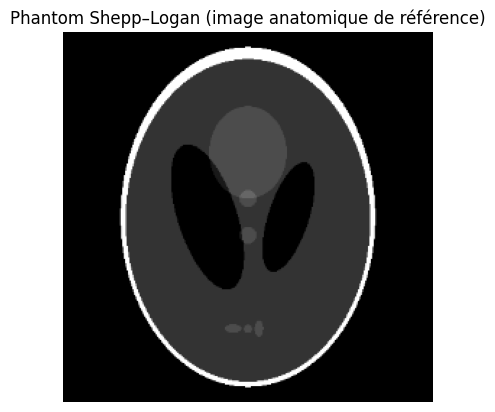

In [3]:
phantom = shepp_logan_phantom()
phantom = resize(phantom, (256, 256))
phantom = (phantom - phantom.min()) / (phantom.max() - phantom.min())

plt.imshow(phantom, cmap='gray')
plt.title("Phantom Shepp–Logan (image anatomique de référence)")
plt.axis('off')
plt.show()

# 2️ Simulation IRM

**Principe :**
En IRM, l’image est obtenue à partir de la **transformée de Fourier (k-space)**.  
On va :
1. Transformer l’image dans le domaine de Fourier (k-space).  
2. Ajouter un **bruit de Poisson** pour simuler le bruit du signal.  
3. Revenir dans le domaine spatial avec la **transformée inverse (IFFT)**.  
4. Appliquer un **filtre de Wiener** pour débruiter.

**Remarque :**
- `fft2()` → transforme l’image dans le domaine fréquentiel.  
- `ifft2()` → reconstruction de l’image.  
- `wiener()` → débruitage fréquentiel.



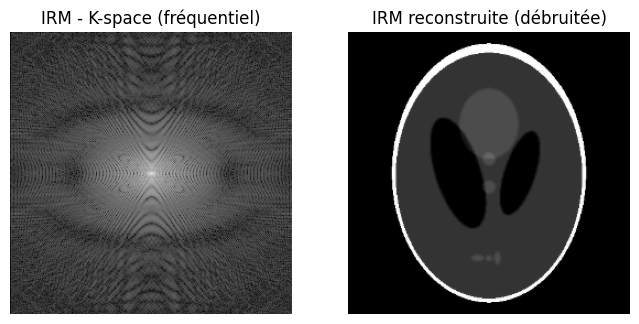

In [ ]:
# 1. Transformée de Fourier directe (k-space)
k_space = fft2(phantom)
k_space_shifted = fftshift(k_space)

# 2. Ajout d’un petit bruit complexe (réel + imaginaire)
noise_real = np.random.normal(0, 0.02, k_space.shape)
noise_imag = np.random.normal(0, 0.02, k_space.shape)
k_space_noisy = k_space_shifted + (noise_real + 1j * noise_imag)

# 3. Rec
# onstruction IRM : revenir dans le domaine spatial
recon_mri = np.abs(ifft2(np.fft.ifftshift(k_space_noisy)))

# 4. Débruitage (filtre de Wiener)
recon_mri_denoised = wiener(recon_mri, (3, 3))

# 5. Normalisation
recon_mri_denoised = (recon_mri_denoised - recon_mri_denoised.min()) / (
    recon_mri_denoised.max() - recon_mri_denoised.min()
)

# Affichage


fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(np.log1p(np.abs(k_space_shifted)), cmap='gray')
ax[0].set_title("IRM - K-space (fréquentiel)")
ax[0].axis('off')

ax[1].imshow(recon_mri_denoised, cmap='gray')
ax[1].set_title("IRM reconstruite (débruitée)")
ax[1].axis('off')
plt.show()



# 3️ Simulation échographique

**Principe :**
L’échographie est sujette à un **bruit speckle** (multiplicatif) et un effet de **beamforming** (flou directionnel).  
Étapes :
1. Ajouter du bruit **speckle** (bruit multiplicatif).  
2. Appliquer un **flou gaussien** pour simuler la réponse du faisceau.  
3. Débruiter avec un **filtre médian** (bon pour les bruits impulsionnels).


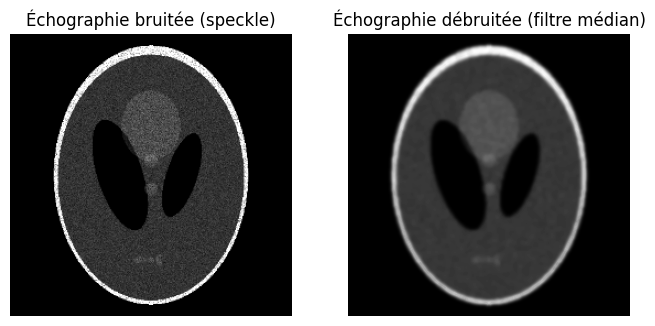

In [5]:
# 1. Bruit speckle (multiplicatif)
speckle = np.random.randn(*phantom.shape) * 0.2
ultrasound = phantom + phantom * speckle
ultrasound = np.clip(ultrasound, 0, 1)

# 2. Flou gaussien
ultrasound_blur = gaussian(ultrasound, sigma=1.5)

# 3. Débruitage médian
ultrasound_denoised = median(ultrasound_blur, footprint=disk(2))

# Affichage
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(ultrasound, cmap='gray')
ax[0].set_title("Échographie bruitée (speckle)")
ax[0].axis('off')

ax[1].imshow(ultrasound_denoised, cmap='gray')
ax[1].set_title("Échographie débruitée (filtre médian)")
ax[1].axis('off')
plt.show()


# 4️ Fusion multimodale (ondelettes / moyenne pondérée)

**But :**
Combiner les avantages des deux modalités :
- IRM → bon contraste anatomique.
- Échographie → texture fine, contours.

**Méthode : ondelettes**
1. Décomposer les deux images par transformée en ondelettes (`pywt.dwt2`).  
2. Fusionner les coefficients en prenant la moyenne pondérée.  
3. Recomposer l’image fusionnée (`pywt.idwt2`).

**Autre approche : moyenne simple (pour comparaison).**


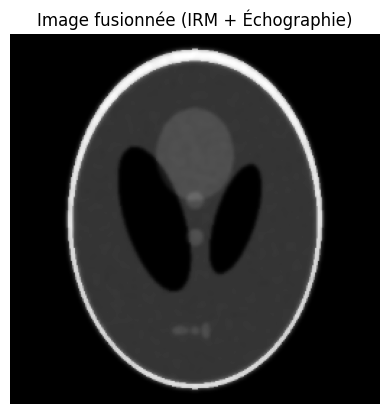

In [6]:
# Décomposition ondelettes
coeffs_mri = pywt.dwt2(recon_mri_denoised, 'db2')
coeffs_ultra = pywt.dwt2(ultrasound_denoised, 'db2')

# Fusion des coefficients (moyenne pondérée)
cA_fused = (coeffs_mri[0] + coeffs_ultra[0]) / 2
cH_fused = (coeffs_mri[1][0] + coeffs_ultra[1][0]) / 2
cV_fused = (coeffs_mri[1][1] + coeffs_ultra[1][1]) / 2
cD_fused = (coeffs_mri[1][2] + coeffs_ultra[1][2]) / 2

# Reconstruction de l’image fusionnée
fusion_wavelet = pywt.idwt2((cA_fused, (cH_fused, cV_fused, cD_fused)), 'db2')

# Normalisation
fusion_wavelet = (fusion_wavelet - fusion_wavelet.min()) / (fusion_wavelet.max() - fusion_wavelet.min())

plt.imshow(fusion_wavelet, cmap='gray')
plt.title("Image fusionnée (IRM + Échographie)")
plt.axis('off')
plt.show()


# 5️ Segmentation automatique (méthode d’Otsu)

**Principe :**
La méthode d’Otsu choisit automatiquement un **seuil d’intensité** qui sépare les zones claires et sombres.  
On l’applique sur :
- le phantom original (référence),
- l’image IRM,
- l’image échographique,
- et l’image fusionnée.

Ensuite on évalue avec des métriques :
- **Dice coefficient**
- **IoU (Intersection over Union)**


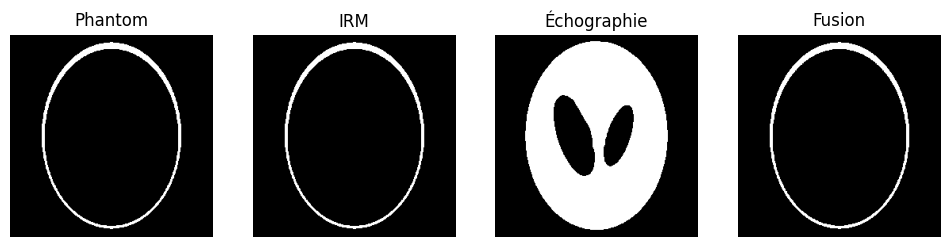

IRM: Dice=0.999, IoU=0.999
Échographie: Dice=0.186, IoU=0.103
Fusion: Dice=0.981, IoU=0.963


In [7]:
def dice_coeff(a, b):
    inter = np.sum(a * b)
    return 2 * inter / (np.sum(a) + np.sum(b))

def iou_coeff(a, b):
    inter = np.sum(a * b)
    union = np.sum((a + b) > 0)
    return inter / union

def segment(image):
    th = threshold_otsu(image)
    return image > th

seg_ref = segment(phantom)
seg_mri = segment(recon_mri_denoised)
seg_ultra = segment(ultrasound_denoised)
seg_fusion = segment(fusion_wavelet)

fig, ax = plt.subplots(1, 4, figsize=(12, 4))
ax[0].imshow(seg_ref, cmap='gray'); ax[0].set_title("Phantom")
ax[1].imshow(seg_mri, cmap='gray'); ax[1].set_title("IRM")
ax[2].imshow(seg_ultra, cmap='gray'); ax[2].set_title("Échographie")
ax[3].imshow(seg_fusion, cmap='gray'); ax[3].set_title("Fusion")
for a in ax: a.axis('off')
plt.show()

# Évaluation
for name, seg in zip(['IRM', 'Échographie', 'Fusion'],
                     [seg_mri, seg_ultra, seg_fusion]):
    print(f"{name}: Dice={dice_coeff(seg_ref, seg):.3f}, IoU={iou_coeff(seg_ref, seg):.3f}")


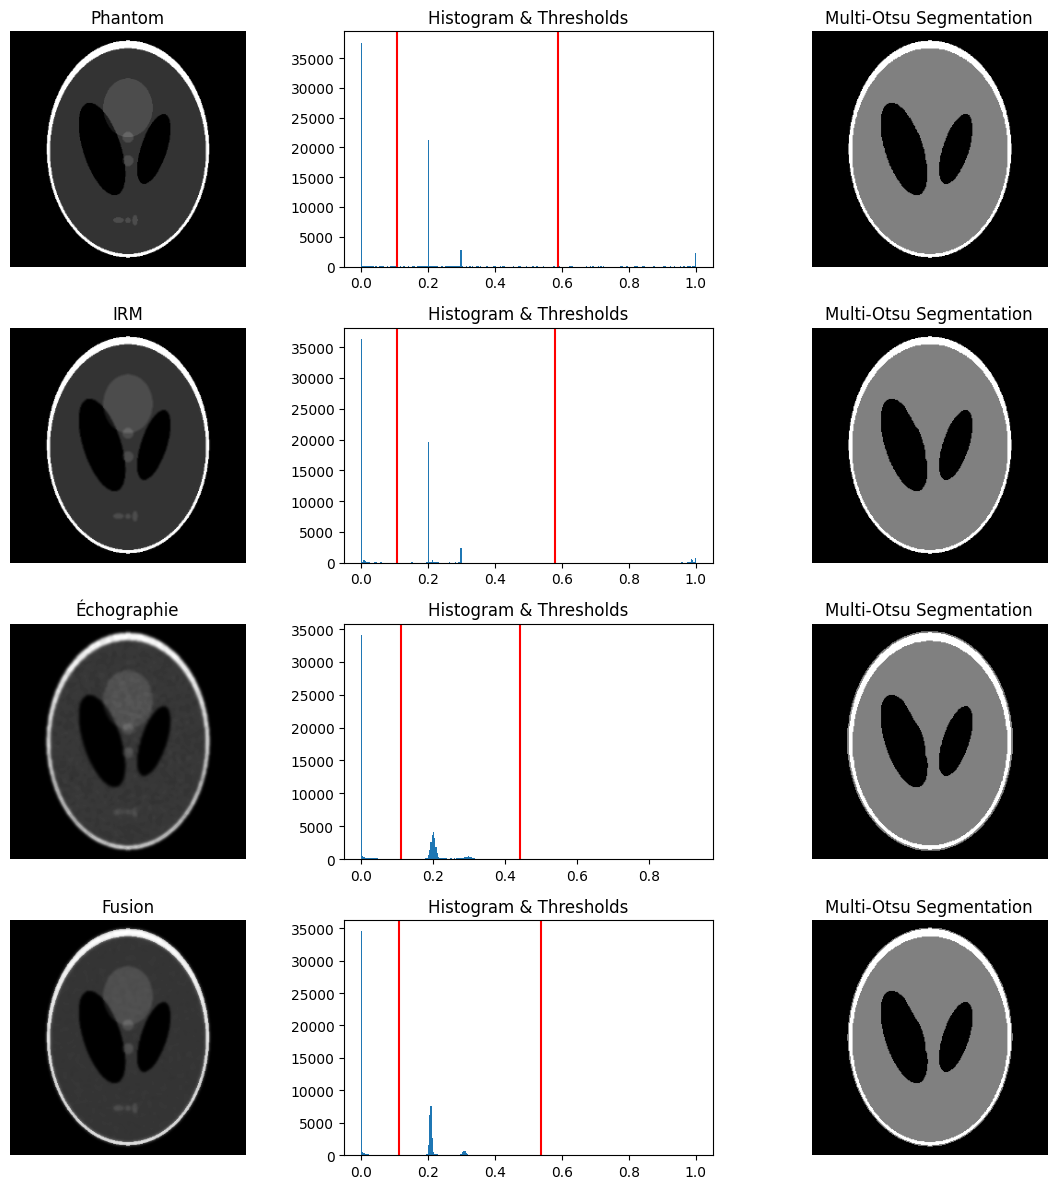

In [20]:
images = [phantom, recon_mri_denoised, ultrasound_denoised, fusion_wavelet]
names = ['Phantom', 'IRM', 'Échographie', 'Fusion']

thresholds_list = []
regions_list = []
for img in images:
    thr = threshold_multiotsu(img, classes=3)
    regions = np.digitize(img, bins=thr)
    thresholds_list.append(thr)
    regions_list.append(regions)

fig, axes = plt.subplots(len(images), 3, figsize=(12, 3 * len(images)))
for i, (img, name, thr, regions) in enumerate(zip(images, names, thresholds_list, regions_list)):
    ax_img = axes[i, 0]
    ax_hist = axes[i, 1]
    ax_seg = axes[i, 2]

    ax_img.imshow(img, cmap='gray')
    ax_img.set_title(name)
    ax_img.axis('off')

    ax_hist.hist(img.ravel(), bins=256)
    for t in thr:
        ax_hist.axvline(t, color='r')
    ax_hist.set_title('Histogram & Thresholds')

    ax_seg.imshow(regions, cmap='gray')
    ax_seg.set_title('Multi-Otsu Segmentation')
    ax_seg.axis('off')

plt.tight_layout()
plt.show()


In [21]:
def safe_bool_mask(x):
    return (np.asarray(x) > 0)

def dice_coeff_safe(a, b):
    a = safe_bool_mask(a).astype(np.uint8)
    b = safe_bool_mask(b).astype(np.uint8)
    inter = np.sum(a & b)
    denom = np.sum(a) + np.sum(b)
    if denom == 0:
        return 1.0
    return 2.0 * inter / denom

def iou_coeff_safe(a, b):
    a = safe_bool_mask(a).astype(np.uint8)
    b = safe_bool_mask(b).astype(np.uint8)
    inter = np.sum(a & b)
    union = np.sum(a | b)
    if union == 0:
        return 1.0
    return inter / union

def otsu_binary(img):
    th = threshold_otsu(img)
    return img > th

def multiotsu_topclass(img, classes=3):
    thr = threshold_multiotsu(img, classes=classes)
    regions = np.digitize(img, bins=thr)
    return regions == regions.max()

# Binary masks using Otsu
seg_ref = otsu_binary(phantom)
seg_mri = otsu_binary(recon_mri_denoised)
seg_ultra = otsu_binary(ultrasound_denoised)
seg_fusion = otsu_binary(fusion_wavelet)

print("Otsu binary segmentation metrics (vs phantom):")
for name, seg in zip(['IRM', 'Échographie', 'Fusion'], [seg_mri, seg_ultra, seg_fusion]):
    print(f"{name}: Dice={dice_coeff_safe(seg_ref, seg):.4f}, IoU={iou_coeff_safe(seg_ref, seg):.4f}")

# Optional: Multi-Otsu top-class masks (compare against phantom Otsu)
seg_mri_m = multiotsu_topclass(recon_mri_denoised)
seg_ultra_m = multiotsu_topclass(ultrasound_denoised)
seg_fusion_m = multiotsu_topclass(fusion_wavelet)

print("\nMulti-Otsu (top class) metrics (vs phantom Otsu):")
for name, seg in zip(['IRM', 'Échographie', 'Fusion'], [seg_mri_m, seg_ultra_m, seg_fusion_m]):
    print(f"{name}: Dice={dice_coeff_safe(seg_ref, seg):.4f}, IoU={iou_coeff_safe(seg_ref, seg):.4f}")


Otsu binary segmentation metrics (vs phantom):
IRM: Dice=0.9993, IoU=0.9986
Échographie: Dice=0.1860, IoU=0.1025
Fusion: Dice=0.9813, IoU=0.9634

Multi-Otsu (top class) metrics (vs phantom Otsu):
IRM: Dice=0.9930, IoU=0.9862
Échographie: Dice=0.9325, IoU=0.8735
Fusion: Dice=0.9950, IoU=0.9900


# 6️ Interprétation et Discussion

**Observations possibles :**
- L’IRM a un **meilleur contraste global**, mais moins de texture.  
- L’échographie montre plus de **détails fins**, mais beaucoup de bruit speckle.  
- L’image fusionnée combine les **avantages des deux** : bon contraste ET bonne texture.  
- La **segmentation** sur l’image fusionnée est souvent la plus stable et la plus précise.

**Métriques :**
- Plus le Dice et IoU sont élevés → meilleure correspondance avec la référence.


#  Conclusion

Ce TP a permis de :
- Simuler deux modalités (IRM & échographie) à partir du même phantom.  
- Comprendre les différences de bruit et de rendu entre les modalités.  
- Appliquer une **fusion multimodale** pour combiner contraste et texture.  
- Réaliser une **segmentation automatique** et comparer la qualité selon la modalité.

**Résultats clés :**
- IRM : image claire, peu bruitée.  
- Échographie : image granuleuse (speckle).  
- Fusion : image plus informative et plus précise pour la segmentation.

**Conclusion générale :**
La fusion multimodale améliore la lisibilité des structures anatomiques et la qualité de segmentation,  
ce qui représente un grand intérêt pour le diagnostic médical assisté par ordinateur.
